# Vakuumtechnik

Steigung
Luft: 9.979081e-05 +/- 4.329485e-08 torr/s
Helium: 1.205449e-04 +/- 1.187373e-07 torr/s
Leckrate
Luft: 8.626915e-04 +/- 6.673517e-05 mbar l/s
Helium: 1.042110e-03 +/- 8.118881e-05 mbar l/s


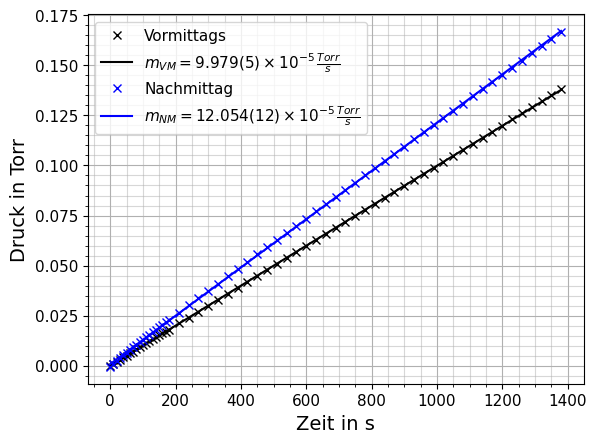

In [ ]:
# Leckratenbestimmung
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

V_fehler = 0.5

def slope_to_leckrate(slope):
    "slope in torr/s"
    return slope*1.33*6.5 # mbar l/s

def leckfehler(slope, slopefehl, volfehl):
    "slope in torr/s, slopefehl in torr/s, volfehl in l"
    return slope*1.33*volfehl + 1.33*6.5*slopefehl # mbar l/s

#data loading
zeit, leckluft, leckhe= np.loadtxt(r'../Messdaten/20260427_Vakuum/leckrate.csv', skiprows=1, unpack=True, delimiter=',')

#modelling
fitluft = linregress(zeit, leckluft)
fithe = linregress(zeit, leckhe)

print("Steigung")
print(f"Luft: {fitluft.slope:e} +/- {fitluft.stderr:e} torr/s")
print(f"Helium: {fithe.slope:e} +/- {fithe.stderr:e} torr/s")

Qluft = (slope_to_leckrate(fitluft.slope), leckfehler(fitluft.slope, fitluft.stderr, V_fehler))
Qhe = (slope_to_leckrate(fithe.slope), leckfehler(fithe.slope, fithe.stderr, V_fehler))

print("Leckrate")
print(f"Luft: {Qluft[0]:e} +/- {Qluft[1]:e} mbar l/s")
print(f"Helium: {Qhe[0]:e} +/- {Qhe[1]:e} mbar l/s")

#plotting
def plotleck(fig, ax): # damit ich mit ax und fig arbeiten kann, die achsen später aber eindeutige namen haben
    ax.plot(zeit, leckluft, "xk", label="Vormittags")
    ax.plot(zeit, fitluft.intercept+fitluft.slope*zeit, "-k", label=r"$m_{VM}=9.979(5)\times10^{-5}\,\frac{Torr}{s}$")
    
    ax.plot(zeit, leckhe, "xb", label="Nachmittag")
    ax.plot(zeit, fithe.intercept+fithe.slope*zeit, "-b", label=r"$m_{NM}=12.054(12)\times10^{-5}\,\frac{Torr}{s}$")

    ax.set_xlabel("Zeit in s", fontsize=14)
    ax.set_ylabel("Druck in Torr", fontsize=14)
    ax.tick_params(labelsize=11)

    ax.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.legend(fontsize=11)

    #plt.savefig(r"../Bilder/Vakuum/Leckraten.pdf")

leckfig, leckax = plt.subplots() # eindeutige Namen für ax und fig
plotleck(leckfig, leckax)

#Leckrate nachmittags höher, da gas durch mehrfaches 15torr hochpumpen an wand adsorbiert und interne leckrate steigt

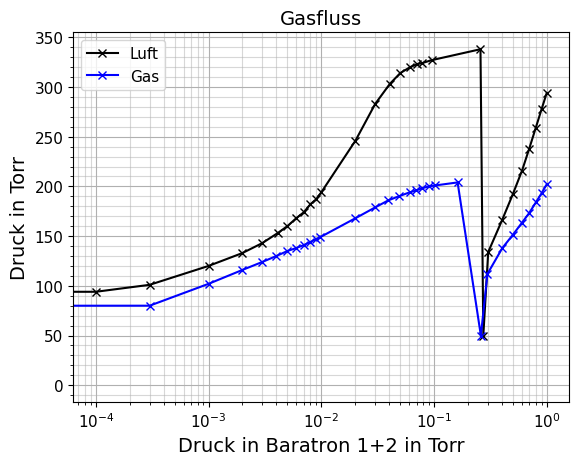

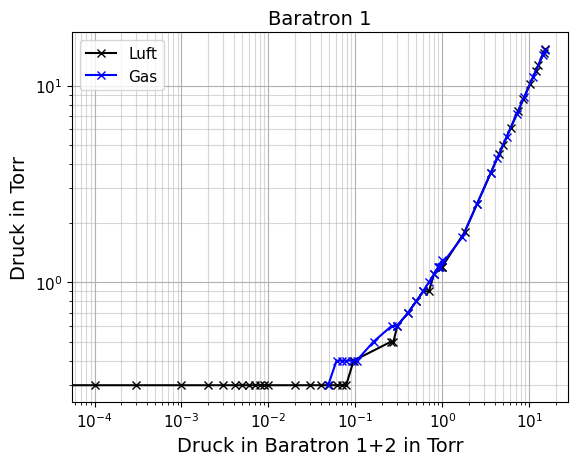

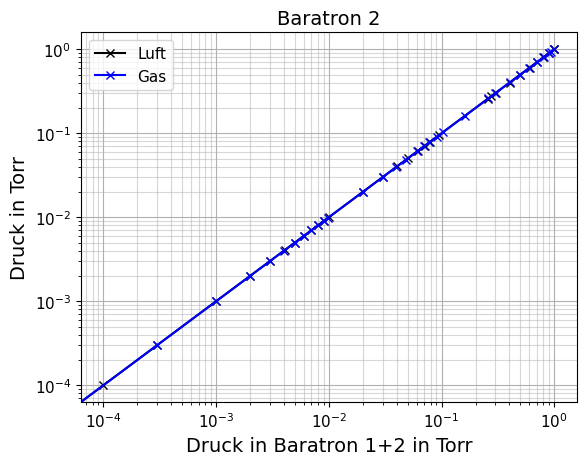

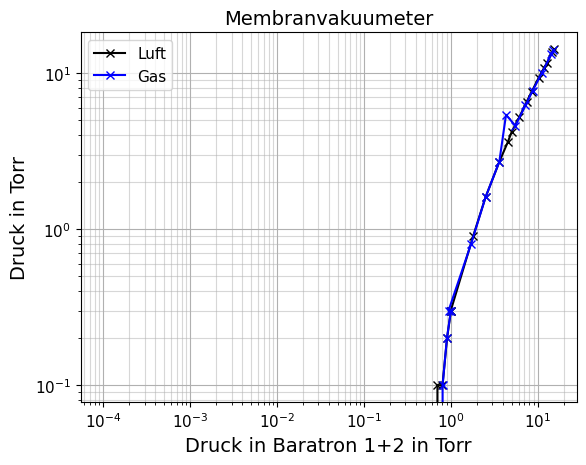

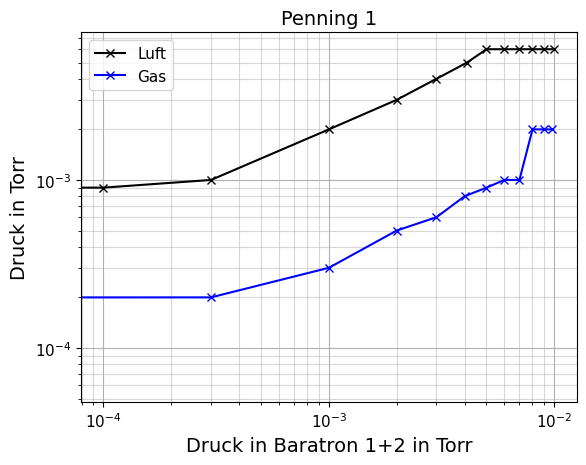

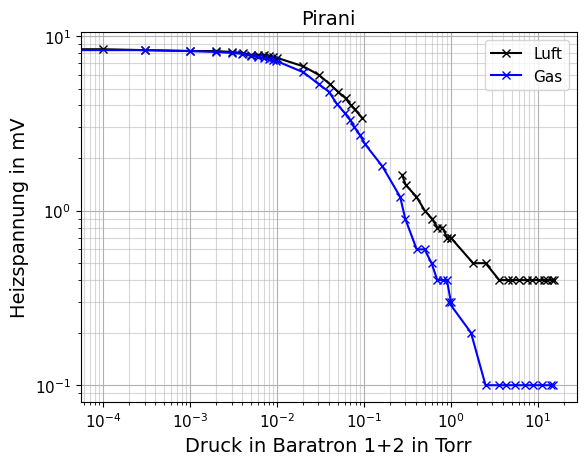

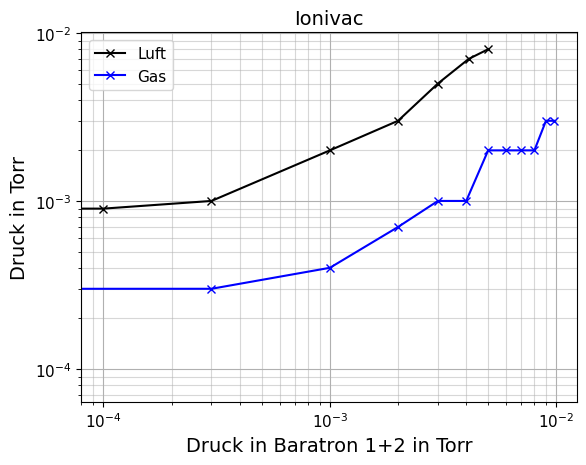

In [ ]:
# Charakterisierung Druckmessköpfe
import numpy as np
import matplotlib.pyplot as plt

dv, bar1, bar2, mem, pen1, pir, ioni = np.genfromtxt(r'../Messdaten/20260427_Vakuum/druckmesskopfkennlinie_luft.csv', skip_header=1, unpack=True, delimiter=',', missing_values="", filling_values=np.nan)
luft = (dv, bar1, bar2, mem, pen1, pir/10, ioni)

dv, bar1, bar2, mem, pen1, pir, ioni = np.genfromtxt(r'../Messdaten/20260427_Vakuum/druckmesskopfkennlinie_he.csv', skip_header=1, unpack=True, delimiter=',', missing_values="", filling_values=np.nan)
he = (dv, bar1, bar2, mem, pen1, pir/10, ioni)


xluft = np.append(luft[1][:13], luft[2][13:])
xhe = np.append(he[1][:10], he[2][10:])

meter = {"Gasfluss":(luft[0], he[0]),
        "Baratron 1":(luft[1], he[1]),
        "Baratron 2":(luft[2], he[2]),
        "Membranvakuumeter":(luft[3], he[3]),
        "Penning 1":(luft[4], he[4]),
        "Pirani":(luft[5], he[5]),
        "Ionivac":(luft[6], he[6])}

for key in meter.keys():
    fig, ax = plt.subplots()
    ax.plot(xluft, meter[key][0], "x-k", label="Luft")
    ax.plot(xhe, meter[key][1], "x-b", label="Gas")
    if key != "Gasfluss":
        ax.loglog()
    else:
        ax.set_xscale("log")

    ax.set_title(key, fontsize=14)

    ax.set_xlabel("Druck in Baratron 1+2 in Torr", fontsize=14)
    if key == "Pirani":
        ax.set_ylabel("Heizspannung in mV", fontsize=14)
    elif key == "Gasfluss":
        ax.set_ylabel("Gasfluss in ")
    else:
        ax.set_ylabel("Druck in Torr", fontsize=14)
    ax.tick_params(labelsize=11)

    ax.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.legend(fontsize=11)

In [ ]:
# Saugvermögen

In [ ]:
# Massenspeltroskopie